# Testeo y Evaluación de YOLO OBB (Oriented Bounding Boxes)

Este notebook permite cargar el mejor modelo entrenado (`best.pt`) y evaluar sus métricas en el conjunto de validación y testeo, además de visualizar predicciones de cajas orientadas (rotadas).

### 1. Instalación de Dependencias y Configuración
Instalamos la librería de Ultralytics (YOLO) y otras dependencias necesarias si es que no están instaladas, y definimos el directorio del dataset.

In [5]:
%pip install ultralytics roboflow matplotlib opencv-python numpy pyyaml

import os
import glob
import random
from ultralytics import YOLO
from IPython.display import Image, display


EXTRACT_DIR = "./dataset_obb"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 40.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.0/250.0 kB 26.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 87.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 97.7 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.18
    Uninstalling idna-3.18:
      Successfully uninstalled idna-3.18
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'y

### 2. Validar el Modelo
Una vez completado el entrenamiento, podemos validar las métricas obtenidas con el mejor modelo guardado.

In [ ]:
# Buscar dinámicamente el archivo best.pt para evitar errores de rutas de Ultralytics
best_weights = glob.glob('**/weights/best.pt', recursive=True)

if best_weights:
    best_path = best_weights[0]
    print(f"Cargando mejor modelo desde: {best_path}")
    best_model = YOLO(best_path)
    # Validar
    metrics = best_model.val()
    print("Métricas de validación calculadas con éxito.\n")

    print("Métricas Generales (Cajas Orientadas - OBB)")
    print(f"Precisión media (mAP50):      {metrics.box.map50:.4f}")
    print(f"Precisión media (mAP50-95):   {metrics.box.map:.4f}")
    print(f"Precisión (Precision):        {metrics.box.mp:.4f}")
    print(f"Exhaustividad (Recall):       {metrics.box.mr:.4f}\n")

    # Mostrar métricas por clase
    print("Métricas por Clase")
    names = best_model.names
    for i, class_name in names.items():
        ap50 = metrics.box.ap50[i]
        ap = metrics.box.ap[i]
        p = metrics.box.p[i]
        r = metrics.box.r[i]
        print(f"Clase {i} ({class_name}):")
        print(f"  mAP50:      {ap50:.4f}")
        print(f"  mAP50-95:   {ap:.4f}")
        print(f"  Precision:  {p:.4f}")
        print(f"  Recall:     {r:.4f}\n")
else:
    print("ERROR: No se encontró el archivo best.pt. Asegúrate de haber completado el entrenamiento.")

Ultralytics 8.4.67 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n-obb summary (fused): 132 layers, 2,446,992 parameters, 0 gradients, 5.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 21.0±5.8 MB/s, size: 49.9 KB)
val: Scanning /content/TPI-Rede-Neuronales/data/dataset_obb/test/labels... 15 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 15/15 254.5it/s 0.1s
val: New cache created: /content/TPI-Rede-Neuronales/data/dataset_obb/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 2.0it/s 0.5s
                   all         15         60      0.826      0.638      0.715      0.477
                TT Net         14         18      0.914      0.594      0.742      0.551
             TT Racket         15         24      0.865      0.542      0.568      0.352
              TT Table         15         18      0.698      0.778      0.835      0.527
Speed: 0.9ms preprocess, 8.0ms

### 3. Visualizar Métricas y Gráficos del Entrenamiento
YOLO genera automáticamente gráficos con el progreso de las pérdidas (losses) y las precisiones (mAP50, mAP50-95) a lo largo de las épocas, así como la matriz de confusión.

Cargando resultados de la carpeta: runs/runs/tenis_mesa_obb_run/
Curvas de Pérdidas y Métricas (mAP50 / mAP50-95)


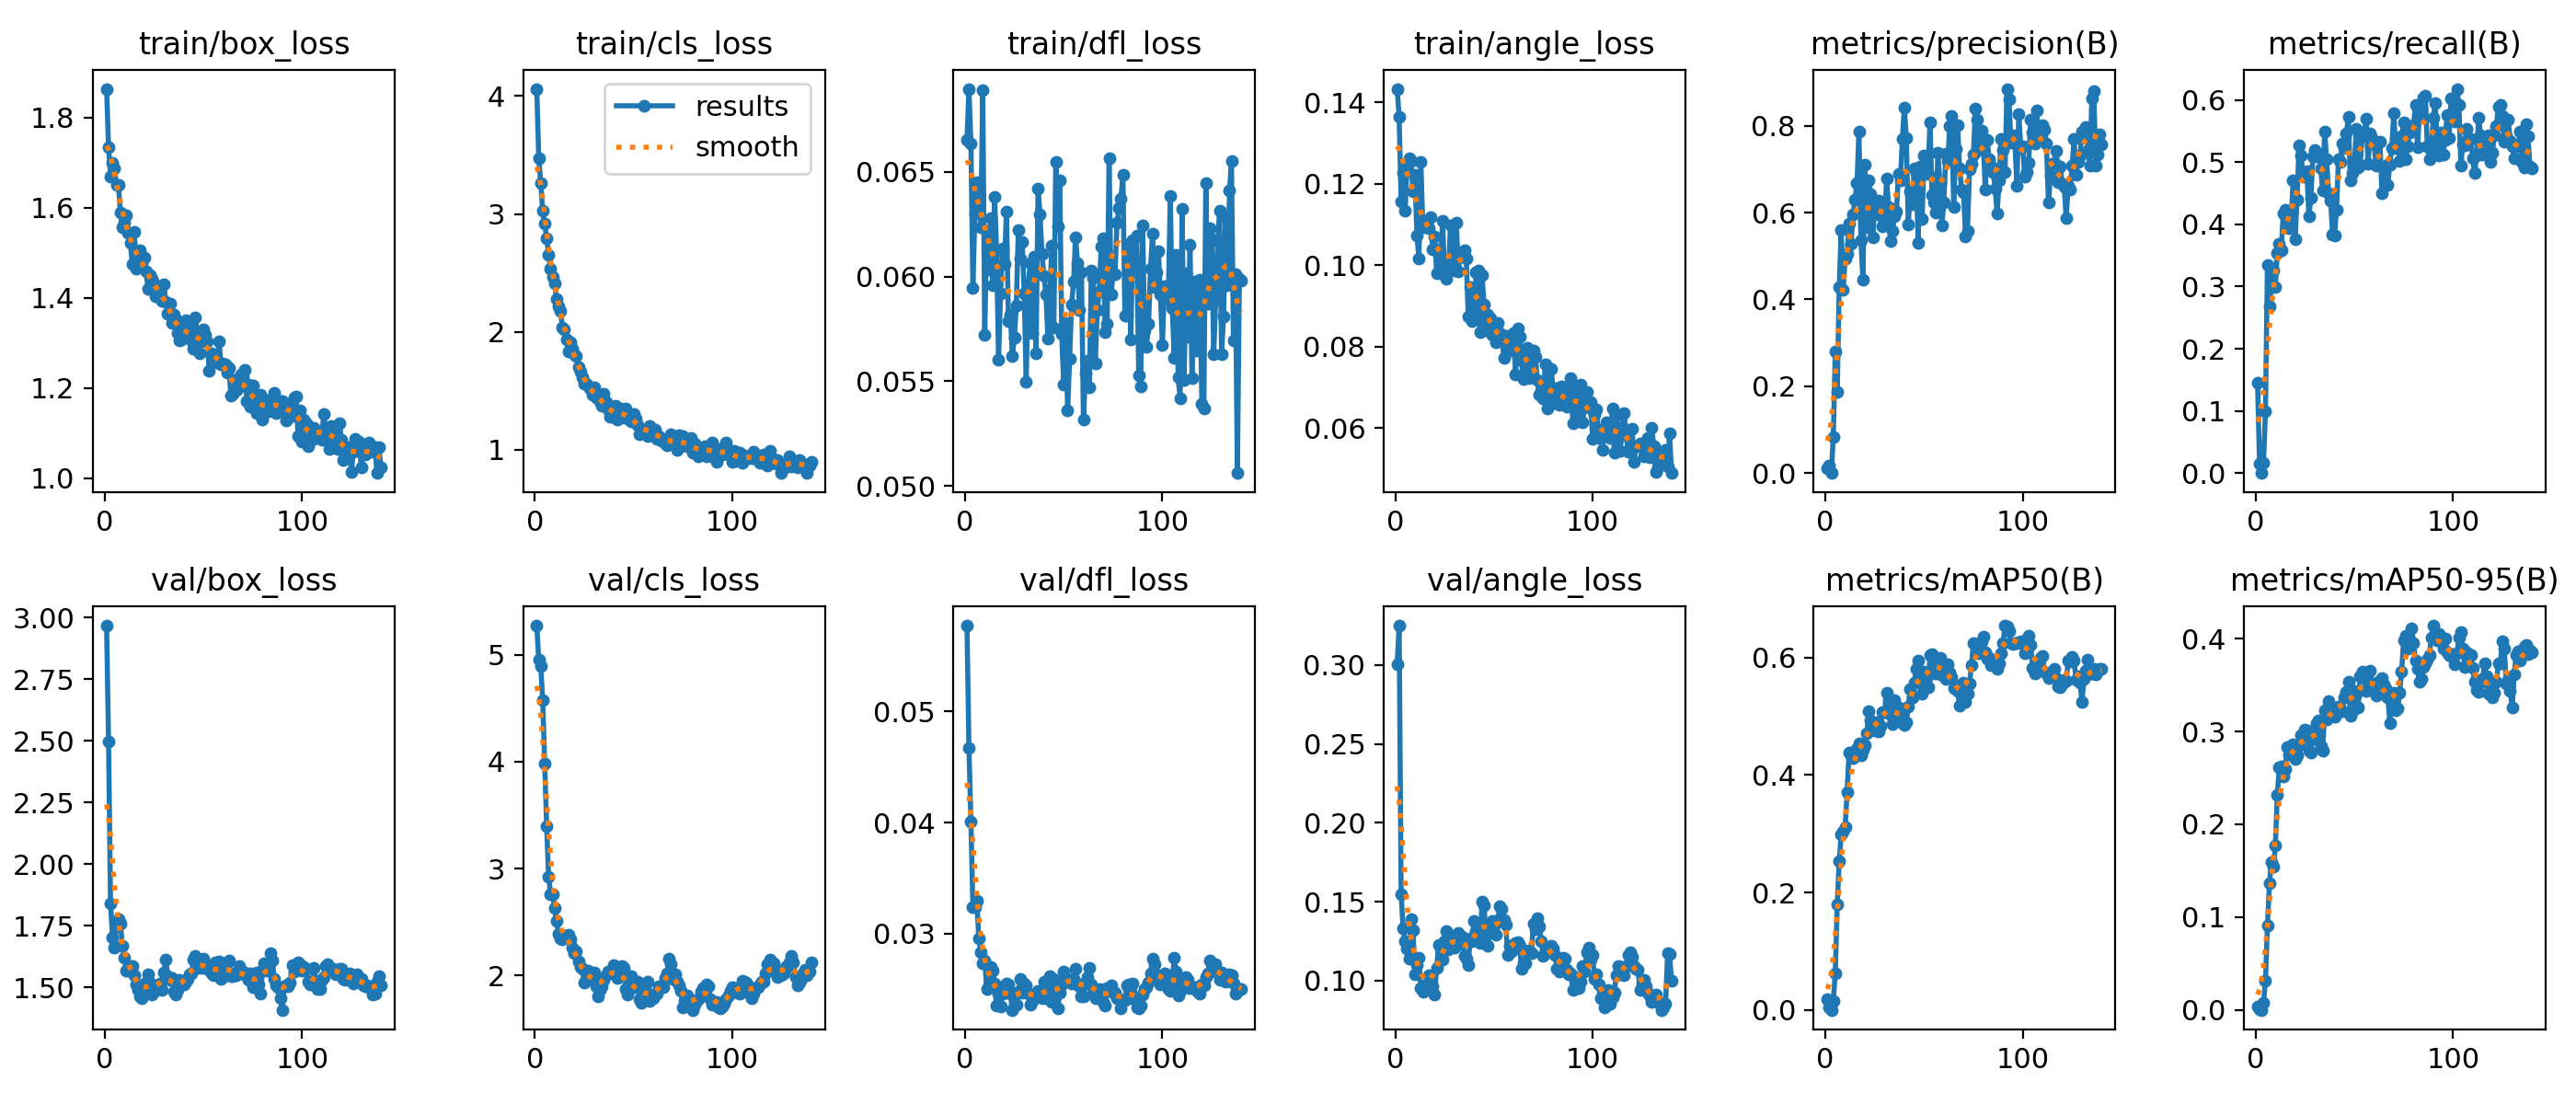


Matriz de Confusión


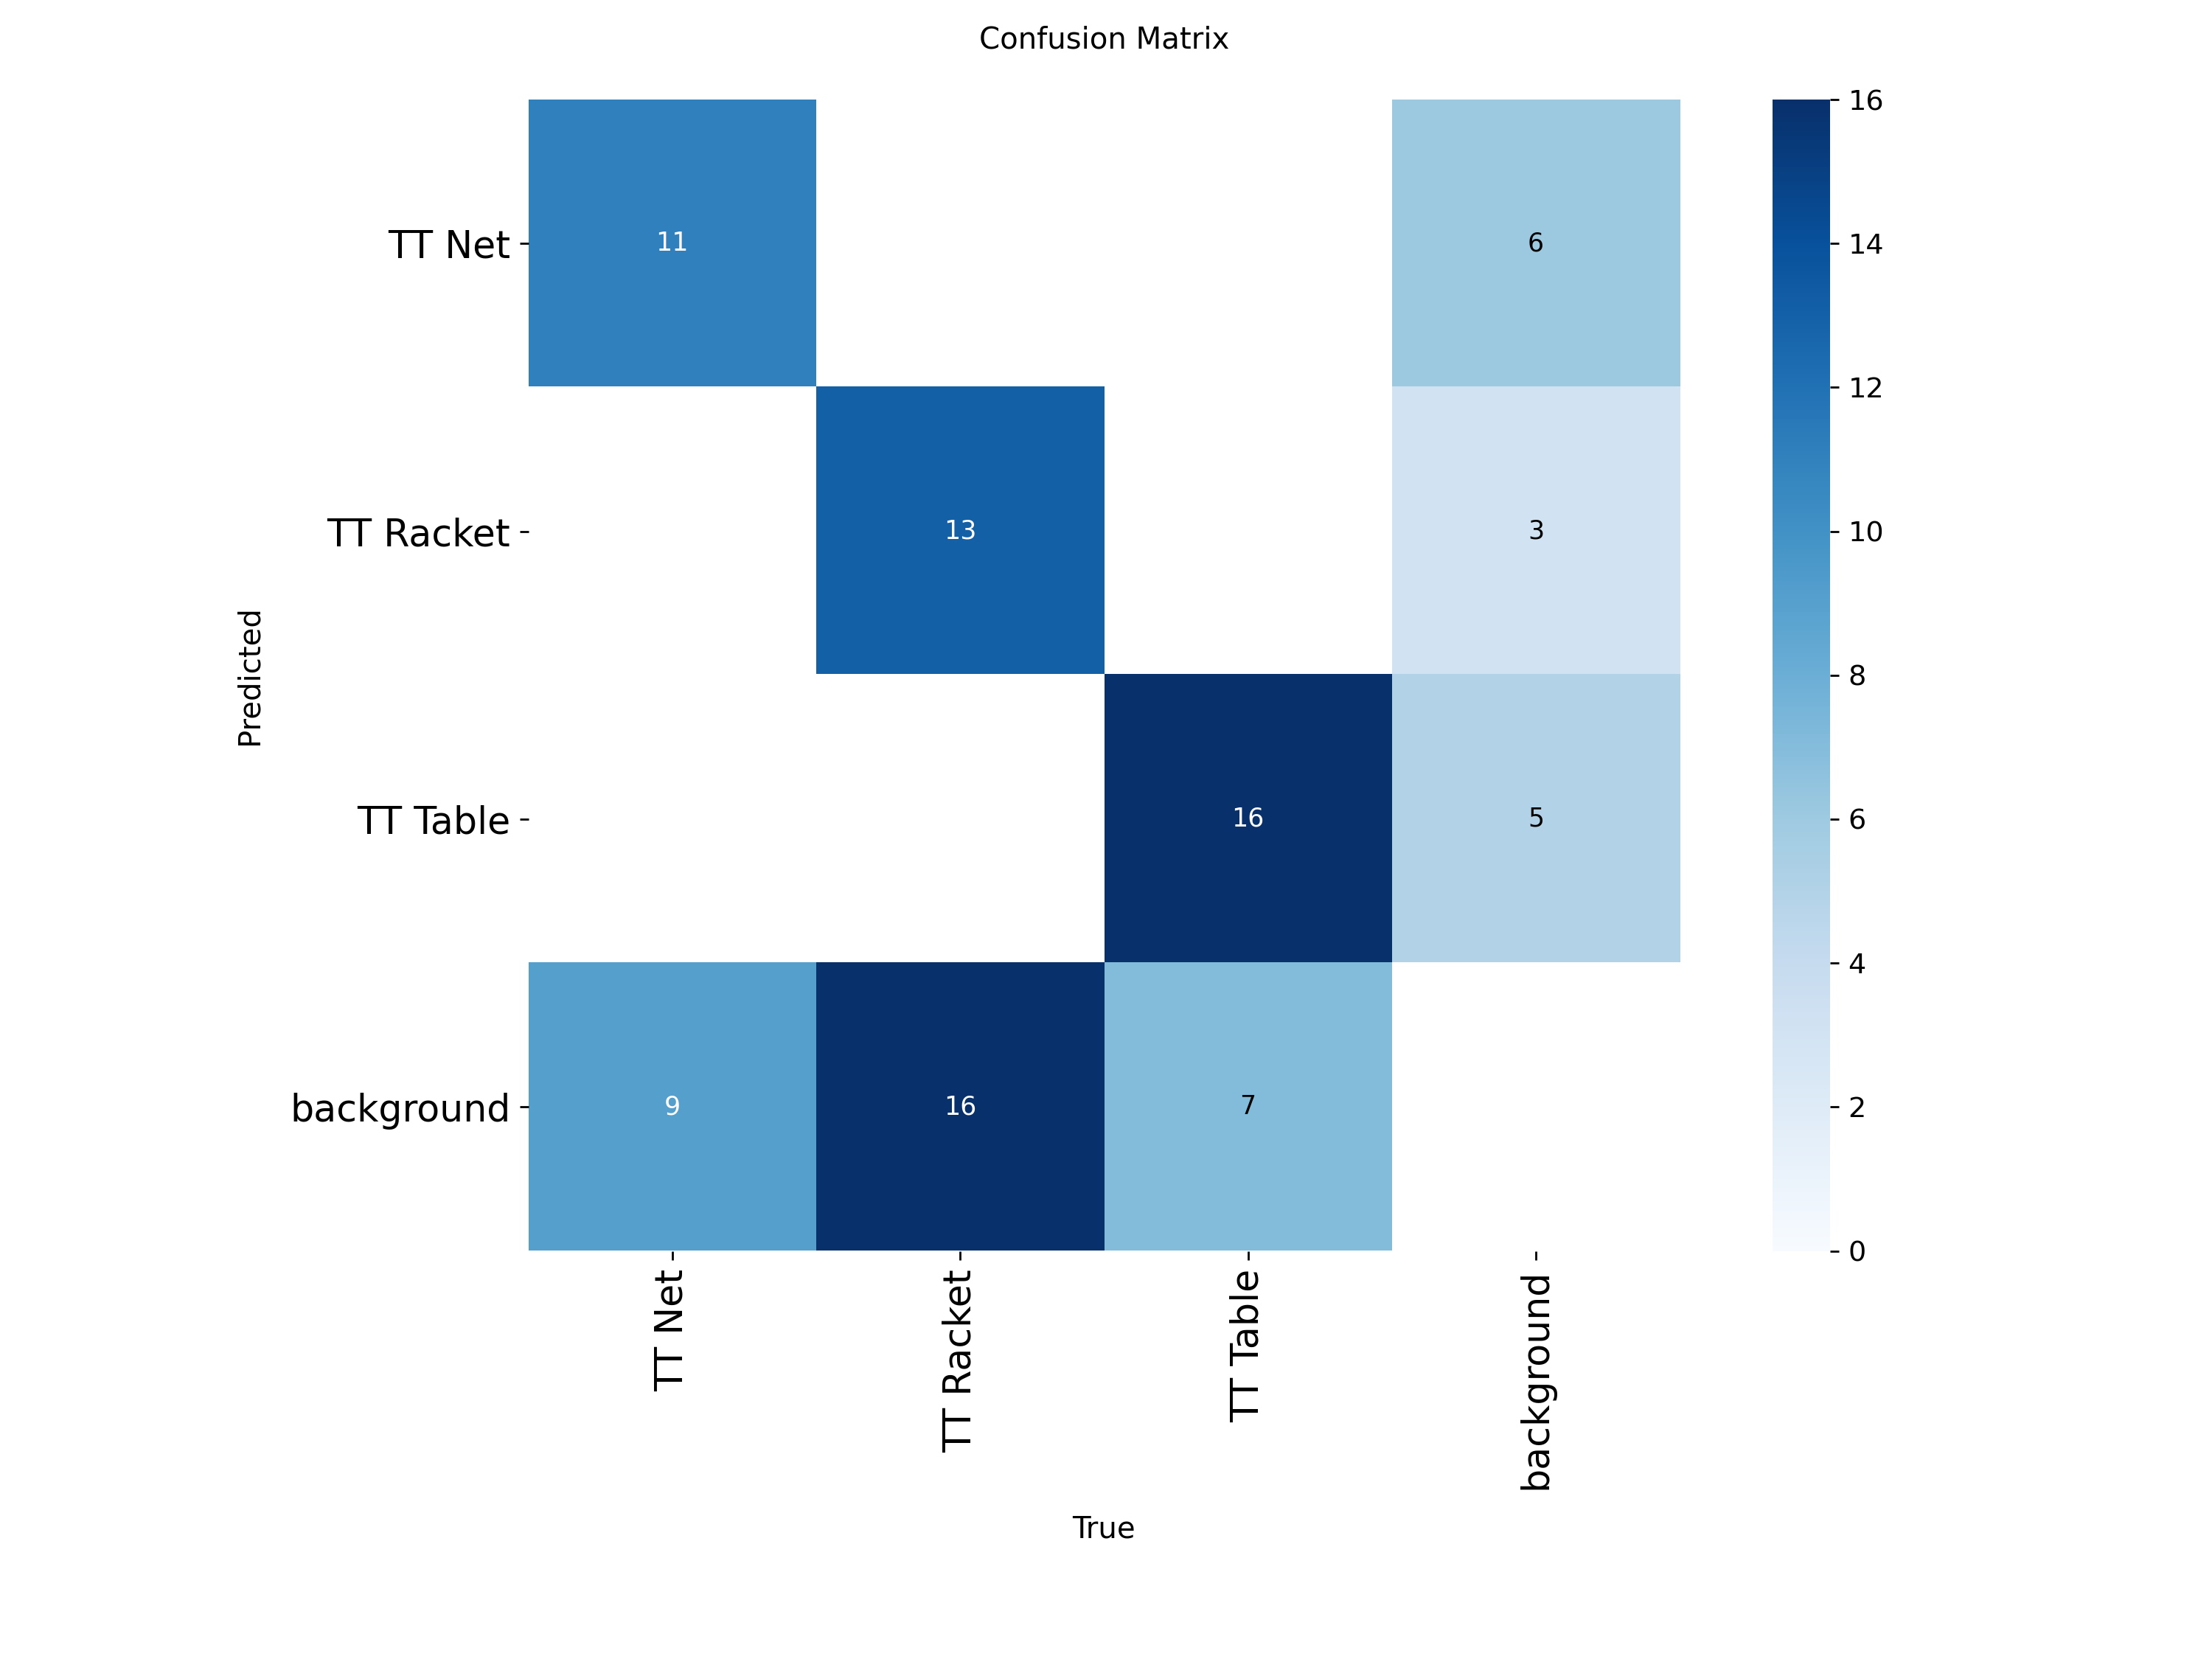

In [ ]:
# Encontrar dinámicamente la carpeta del entrenamiento
results_dirs = glob.glob('**/tenis_mesa_obb_run/', recursive=True)

if results_dirs:
    results_dir = results_dirs[0]
    print(f"Cargando resultados de la carpeta: {results_dir}")

    # 1. Mostrar gráfico de pérdidas y métricas del entrenamiento
    results_png = os.path.join(results_dir, 'results.png')
    if os.path.exists(results_png):
        print("Curvas de Pérdidas y Métricas (mAP50 / mAP50-95)")
        display(Image(filename=results_png, width=800))
    else:
        print("No se encontró results.png en el directorio de resultados.")

    # 2. Mostrar la Matriz de Confusión
    confusion_matrix_png = os.path.join(results_dir, 'confusion_matrix.png')
    if os.path.exists(confusion_matrix_png):
        print("\nMatriz de Confusión")
        display(Image(filename=confusion_matrix_png, width=600))
    else:
        print("No se encontró la matriz de confusión.")
else:
    print("ERROR: No se encontró la carpeta del entrenamiento tenis_mesa_obb_run.")

### 4. Realizar Predicciones en Imágenes de Testeo (Inferencia OBB)
Hacemos predicciones en algunas imágenes del conjunto de testeo para visualizar cómo el modelo detecta y orienta las cajas de tenis de mesa (red, raqueta, mesa).

✅ Cargando mejor modelo desde: /content/runs/runs/tenis_mesa_obb_run/weights/best.pt
✅ Se encontraron 15 imágenes de prueba.
🚀 Procesando inferencia en lote para 6 imágenes...

0: 640x640 1 TT Net, 1 TT Racket, 1 TT Table, 5.5ms
1: 640x640 1 TT Net, 1 TT Racket, 2 TT Tables, 5.5ms
2: 640x640 1 TT Net, 1 TT Racket, 1 TT Table, 5.5ms
3: 640x640 2 TT Nets, 2 TT Rackets, 1 TT Table, 5.5ms
4: 640x640 1 TT Net, 1 TT Racket, 1 TT Table, 5.5ms
5: 640x640 1 TT Net, 2 TT Rackets, 1 TT Table, 5.5ms
Speed: 1.7ms preprocess, 5.5ms inference, 0.2ms postprocess per image at shape (1, 3, 640, 640)


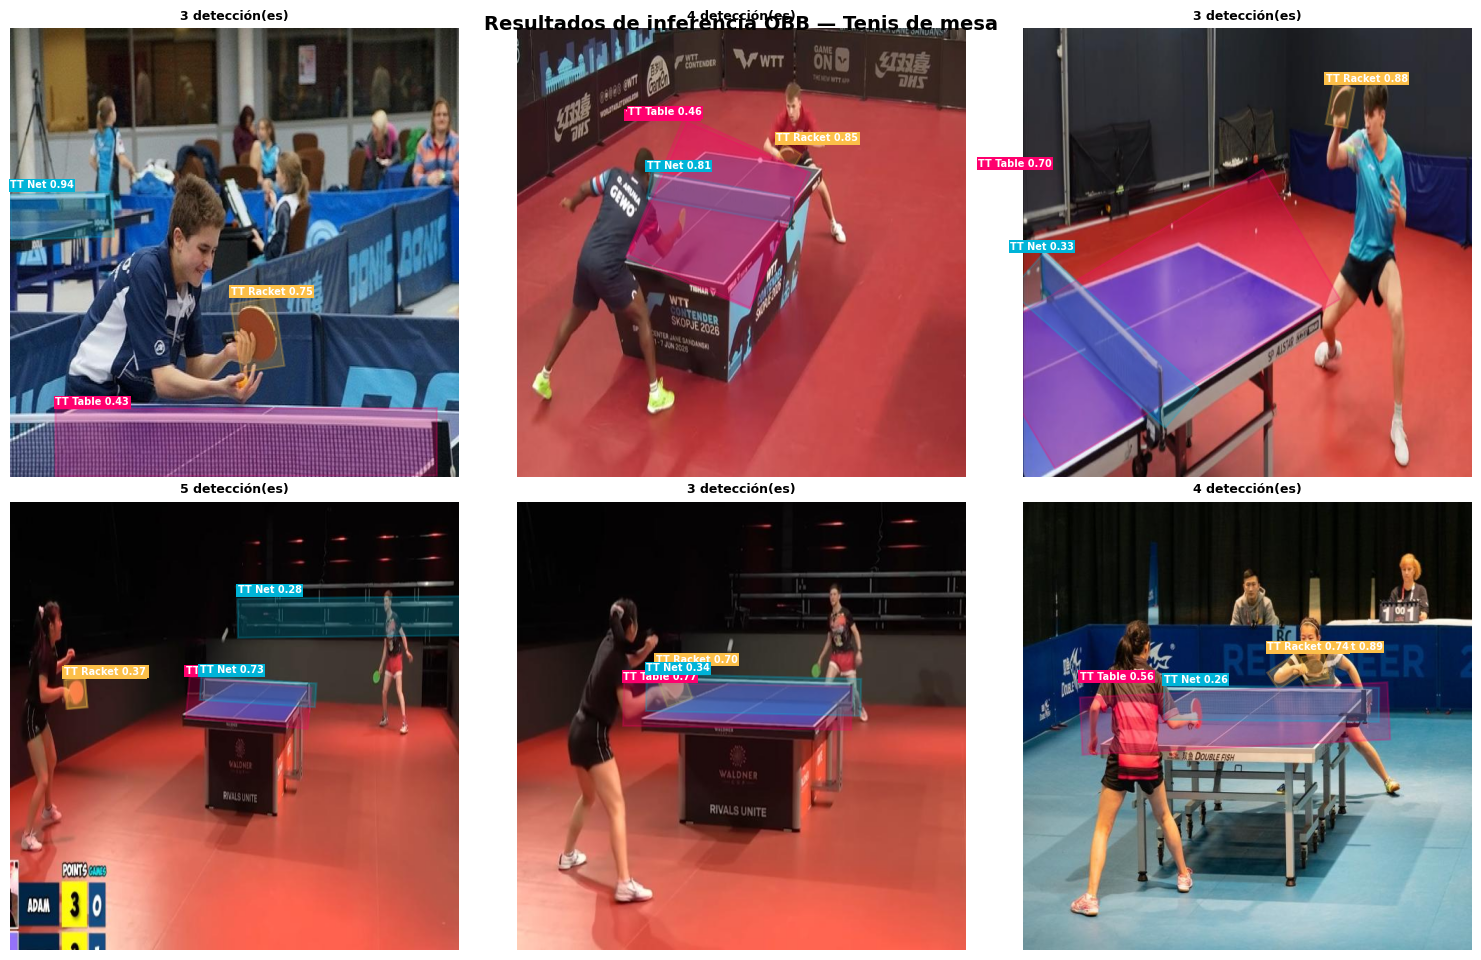

✅ Gráfica generada y guardada como 'sample_predictions_obb.png'.


In [ ]:
import cv2
import random
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon as MplPolygon

ruta_dir_imagenes = '../data/dataset_obb/test/images'
ruta_pesos = '../runs/obb/tenis_mesa_obb_run/weights/best.pt'

# Mapeo de nombres de clases para las etiquetas de Matplotlib
class_names = {0: 'TT Net', 1: 'TT Racket', 2: 'TT Table'}
colors = ['#00b4d8', '#fcbf49', '#ff006e'] 

# Buscar imágenes reales (.png, .jpg, .jpeg) 
test_images = glob.glob(os.path.join(ruta_dir_imagenes, '*.png')) + \
              glob.glob(os.path.join(ruta_dir_imagenes, '*.jpg')) + \
              glob.glob(os.path.join(ruta_dir_imagenes, '*.jpeg'))

if os.path.exists(ruta_pesos) and test_images:
    print(f"Cargando mejor modelo desde: {ruta_pesos}")
    print(f"Se encontraron {len(test_images)} imágenes de prueba.")

    model = YOLO(ruta_pesos)

    # Seleccionar una muestra de hasta 6 imágenes
    sample_images = random.sample(test_images, min(6, len(test_images)))
    print(f"Procesando inferencia en lote para {len(sample_images)} imágenes...")

    predictions = model.predict(
        source=sample_images,
        conf=0.25,
        iou=0.45,
        imgsz=640,
        save=False
    )

    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes_flat = axes.flatten()

    for idx, (ax, result) in enumerate(zip(axes_flat, predictions)):
        img = cv2.cvtColor(result.orig_img, cv2.COLOR_BGR2RGB)
        ax.imshow(img)

        cant_detecciones = 0

        # Validar si el modelo encontró cajas orientadas (OBB)
        if result.obb is not None and len(result.obb) > 0:
            cant_detecciones = len(result.obb)

            for obb in result.obb:
                cid = int(obb.cls[0])    # ID de clase
                conf = float(obb.conf[0]) # Confianza de la predicción
                c = colors[cid % len(colors)]

                # Extraer los 4 vértices del rectángulo rotado [x1, y1, x2, y2, x3, y3, x4, y4]
                polygon_pts = obb.xyxyxyxy[0].cpu().numpy()

                # Dibujar el polígono rotado con transparencia
                ax.add_patch(MplPolygon(polygon_pts, closed=True,
                             edgecolor=c, facecolor=c, alpha=0.25, lw=1.5))

                # Calcular el punto superior izquierdo del polígono para posicionar el texto
                x_min, y_min = polygon_pts.min(axis=0)
                ax.text(x_min, y_min - 4, f"{class_names[cid]} {conf:.2f}",
                        color='white', fontsize=7, fontweight='bold',
                        bbox=dict(facecolor=c, pad=1, edgecolor='none'))

        ax.set_title(f"{cant_detecciones} detección(es)", fontsize=9, fontweight='semibold')
        ax.axis('off')

    # Ocultar ejes vacíos si hay menos de 6 imágenes en la muestra
    for i in range(len(predictions), len(axes_flat)):
        axes_flat[i].axis('off')

    plt.suptitle('Resultados de inferencia OBB — Tenis de mesa', fontsize=14, fontweight='bold', y=0.95)
    plt.tight_layout()

    plt.savefig("sample_predictions_obb.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("Gráfica generada y guardada como 'sample_predictions_obb.png'.")

else:
    if not os.path.exists(ruta_pesos):
        print(f"ERROR: No existe el archivo de pesos en la ruta: {ruta_pesos}")
    if not test_images:
        print(f"ERROR: No se encontraron imágenes en la ruta: {ruta_dir_imagenes}")